In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.datasets import load_iris
from sklearn.model_selection import KFold

In [10]:
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['species'] = iris.target
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

In [11]:
import math
def euclidean_distance(x1,x2):
    return np.sqrt(np.sum((x2-x1)**2))


In [12]:
class KNN:
    def __init__(self, k):
        self.k = k

    def fit(self, X, y):
        self.X_train = X
        self.y_train = y

    def predict(self, X):
        return np.array([self._predict(x) for x in X])

    def _predict(self, x):
        distances = [euclidean_distance(x, x_train) for x_train in self.X_train]
        k_indices = np.argsort(distances)[:self.k]
        k_nearest_labels = [self.y_train[i] for i in k_indices]
        most_common = Counter(k_nearest_labels).most_common(1)
        return most_common[0][0]

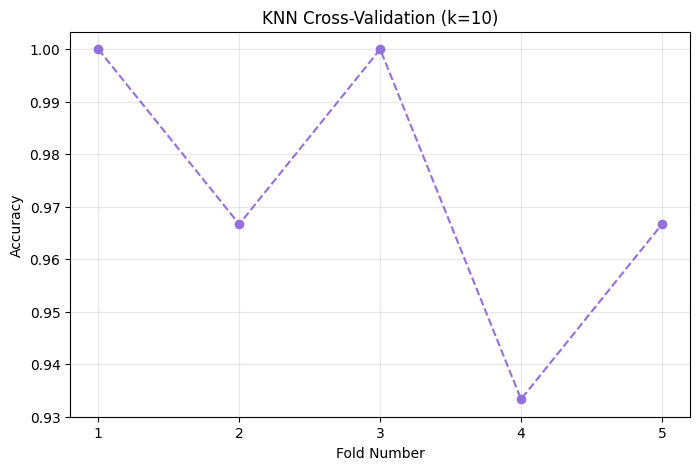

Mean Accuracy: 0.9733


In [ ]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
fold_accuracies = []
for train_index, test_index in kf.split(X):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    k_value = int(np.sqrt(len(X_train)))
    model = KNN(k=k_value)
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    
    accuracy = np.sum(predictions == y_test) / len(y_test)
    fold_accuracies.append(accuracy)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 6), fold_accuracies, marker='o', linestyle='--', color='mediumpurple')
plt.title(f'KNN Cross-Validation (k={int(np.sqrt(len(X)*(4/5)))})')
plt.xlabel('Fold Number')
plt.ylabel('Accuracy')
plt.xticks(range(1, 6))
plt.grid(True, alpha=0.3)
plt.show()

print(f"Mean Accuracy: {np.mean(fold_accuracies):.4f}")

In [27]:
k_range = range(1, 31) 
mean_accuracies = []

for k in k_range:
    fold_accuracies = []
    for train_index, test_index in kf.split(X):
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]
        
        model = KNN(k=k) 
        model.fit(X_train, y_train)
        predictions = model.predict(X_test)
        
        accuracy = np.sum(predictions == y_test) / len(y_test)
        fold_accuracies.append(accuracy)
    
    mean_accuracies.append(np.mean(fold_accuracies))

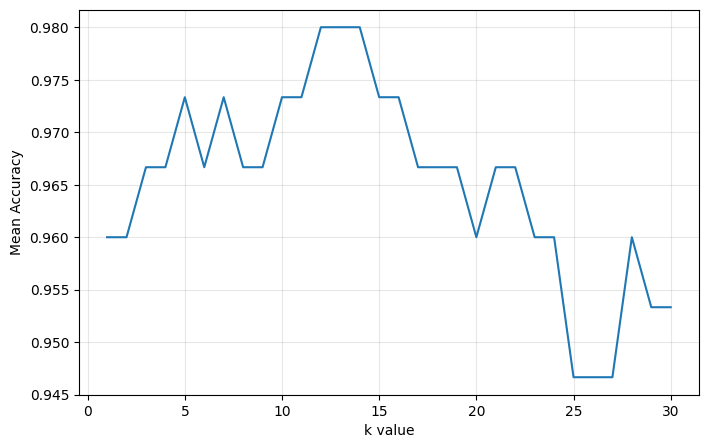

In [32]:
plt.figure(figsize=(8, 5))
plt.plot(range(1,31),mean_accuracies)
plt.xlabel('k value')
plt.ylabel('Mean Accuracy')
plt.grid(True, alpha=0.3)
plt.show()